In [56]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

### Importing previous data and models

In [57]:
vectorizer = pickle.load(open("saved_models/tfidf_vectorizer.pkl", "rb"))
nb_model   = pickle.load(open("saved_models/nb_model.pkl","rb"))
svm_model  = pickle.load(open("saved_models/svm_model.pkl","rb"))

X_test_text = pd.read_csv("data/X_test_text.csv").iloc[:,0].values
y_test      = np.load("data/y_test.npy")

feature_names = vectorizer.get_feature_names_out()

### Defining log based func for Naive Bayes

In [58]:
log_prob_fake = nb_model.feature_log_prob_[1]
log_prob_real = nb_model.feature_log_prob_[0]
log_odds = log_prob_fake - log_prob_real #Similar to dividing probabilities

## A large positive value => word leans heavily fake and large negative value => word leans heavly on real

term_importance = pd.DataFrame({'term': feature_names,'log_odds': log_odds}).sort_values('log_odds', ascending=False)

### Visualizing TOP fake vs real words

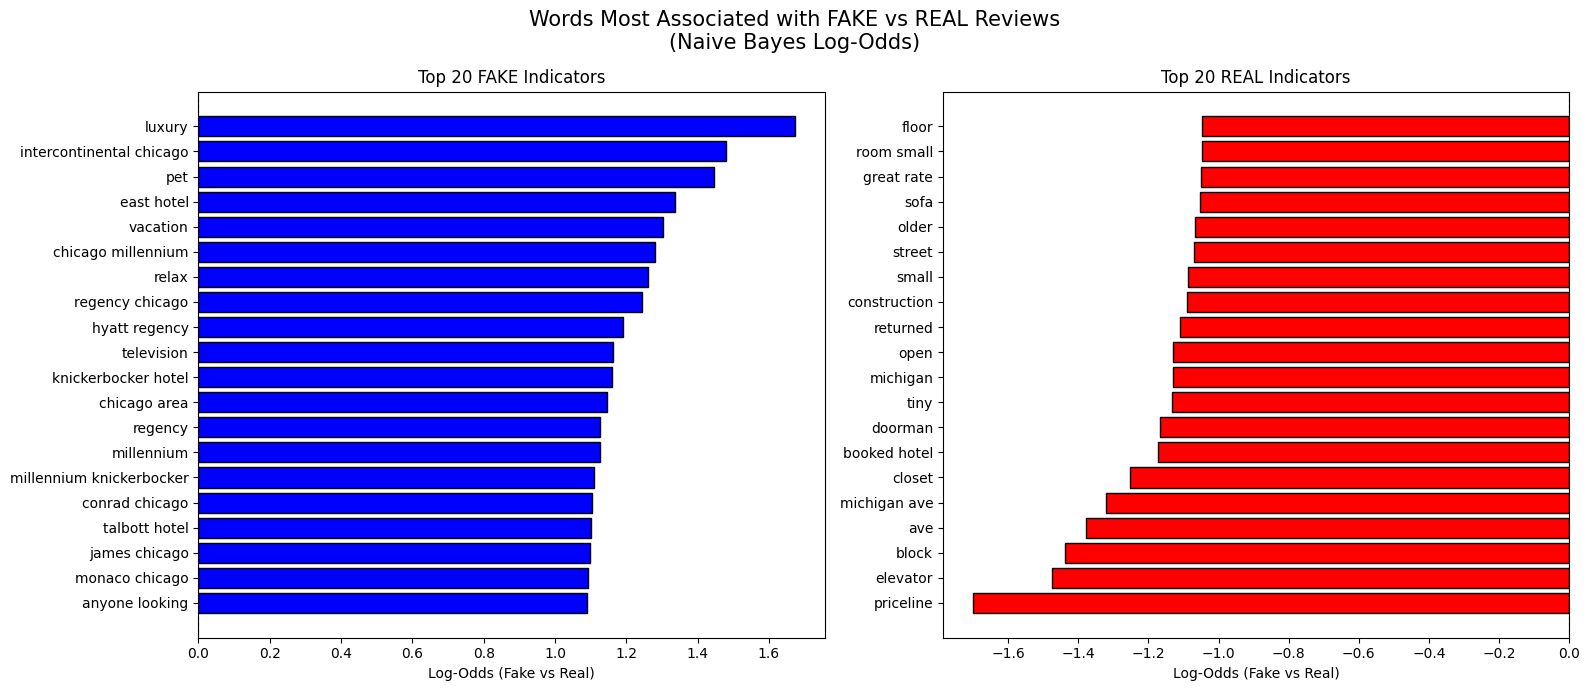

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Words Most Associated with FAKE vs REAL Reviews\n(Naive Bayes Log-Odds)", fontsize=15)

top_fake_terms = term_importance.head(20)
top_real_terms = term_importance.tail(20).sort_values('log_odds')


axes[0].barh(top_fake_terms['term'][::-1],top_fake_terms['log_odds'][::-1], color='blue', edgecolor='black')
axes[0].set_title("Top 20 FAKE Indicators", fontsize=12)
axes[0].set_xlabel("Log-Odds (Fake vs Real)")
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')


axes[1].barh(top_real_terms['term'], top_real_terms['log_odds'], color='red', edgecolor='black')
axes[1].set_title("Top 20 REAL Indicators", fontsize=12)
axes[1].set_xlabel("Log-Odds (Fake vs Real)")
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig("plots/word_importance_global.png", dpi=150, bbox_inches='tight')
plt.show()

## WORD HIGHLIGHTER

In [60]:
def highlight_review(raw_review, model, vectorizer, feature_names, log_odds, top_n=10):
    import re, nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet',   quiet=True)

    lemmatizer = WordNetLemmatizer()
    negation_words = {"no","not","nor","never","neither","without",
                      "nobody","nothing","nowhere","hardly","barely"}
    stop_words = set(stopwords.words('english')) - negation_words

    text = raw_review.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    clean  = ' '.join(tokens)

    tfidf_vec = vectorizer.transform([clean])

    prediction = model.predict(tfidf_vec)[0]
    proba      = model.predict_proba(tfidf_vec)[0]
    confidence = proba[prediction]

    vocab = {term: idx for term, idx in vectorizer.vocabulary_.items()}
    word_scores = {}

    for token in set(tokens):
        if token in vocab:
            idx = vocab[token]
            tfidf_val = tfidf_vec[0, idx]
            if tfidf_val > 0:
                word_scores[token] = log_odds[idx]

    return prediction, confidence, word_scores, clean

In [61]:
def print_highlighted_review(raw_review, model, vectorizer,feature_names, log_odds, top_n=8):
    
    pred, conf, word_scores, clean = highlight_review(raw_review, model, vectorizer, feature_names, log_odds, top_n)

    label = "FAKE" if pred == 1 else "REAL"
    print(f"VERDICT : {label}")
    print(f"Confidence : {conf*100:.2f}%")

    if not word_scores:
        print("No recognizable words found in the vocabulary")
        return

    sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)

    print(f"TOP 'FAKE' indicating words in this review:")
    for word, score in sorted_words[:top_n//2]:
        bar = "⬜" * int(abs(score) * 5) 
        print(f"{word:<20} score={score:+.3f}  {bar}")

    print(f"Top 'REAL' indicating words in this review:")
    for word, score in sorted(word_scores.items(), key=lambda x: x[1])[:top_n//2]:
        bar = "⬜" * int(abs(score) * 5)
        print(f"{word:<20} score={score:+.3f}  {bar}")

    print(f"Cleaned review tokens: {clean[:200]}")

## Testing

In [62]:
print("TESTING WORD HIGHLIGHTERT")

fake_idx = np.where(y_test == 1)[0][0]
real_idx = np.where(y_test == 0)[0][0]

for idx, label in [(fake_idx, "FAKE"), (real_idx, "REAL")]:
    print(f"Testing a known {label} review:")
    print(f"Raw: {X_test_text[idx][:150]}...")
    print_highlighted_review(X_test_text[idx], svm_model, vectorizer, feature_names, log_odds)

TESTING WORD HIGHLIGHTERT
Testing a known FAKE review:
Raw: international chicago magnificent mile shrouded glamour underneath facade fade away classical architectural landmark translated old boring found hotel...
VERDICT : REAL
Confidence : 83.02%
TOP 'FAKE' indicating words in this review:
staying              score=+0.671  ⬜⬜⬜
chicago              score=+0.660  ⬜⬜⬜
ever                 score=+0.384  ⬜
recommend            score=+0.371  ⬜
Top 'REAL' indicating words in this review:
small                score=-1.088  ⬜⬜⬜⬜⬜
old                  score=-0.675  ⬜⬜⬜
size                 score=-0.636  ⬜⬜⬜
via                  score=-0.566  ⬜⬜
Cleaned review tokens: international chicago magnificent mile shrouded glamour underneath facade fade away classical architectural landmark translated old boring found hotel via google regretted ever since room size small u
Testing a known REAL review:
Raw: stayed sheraton navy pier first weekend november pleased accommodation service upgraded club lev